In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import  load_dotenv

In [2]:
load_dotenv()

True

In [3]:
#subgraph will have  a different state for both parent and child here substate is for the child and parentstate for the parent
#defining substate for the subgraph
class SubState(TypedDict):
    input_text:str
    translated_text:str

In [4]:
subgraph_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [5]:
def translate_text(state:SubState):
    prompt = f"""
    Translate the following text to hindi.
    Keep it natural and clear. Do not add extra content 
    Text:
    {state['input_text']}
    """.strip()
    
    translated_text = subgraph_llm.invoke(prompt).content
    return {"translated_text":translated_text}
    

In [10]:
#building subgraph seperately first

subgraph_builder  = StateGraph(SubState)

subgraph_builder.add_node("translate_text",translate_text)

subgraph_builder.add_edge(START,"translate_text")
subgraph_builder.add_edge("translate_text",END)

subgraph =subgraph_builder.compile()

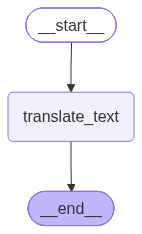

In [11]:
subgraph

In [7]:
#now defining Parent class State
class ParentState(TypedDict):
    question:str
    answer_english :str
    answer_hindi : str

In [18]:
parent_llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [ ]:
#answer is generated in english - node is defined here
def generate_answer(state:ParentState):
    prompt = f"You are a helpful assistant. Answer clearly. \n \n Question: {state['question']}"
    answer = parent_llm.invoke(prompt)
    return {"answer_english":answer}

In [14]:
#transalating subgraph is added here

def translate_answer(state:ParentState):
    #calling subgraph here in the parent graph
    result = subgraph.invoke({'input_text':state['answer_english']})
    return {'answer_hindi':result['translated_text']}

In [15]:
#Building the parent graph 
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer",generate_answer)
parent_builder.add_node("translate",translate_answer)

parent_builder.add_edge(START,"answer")
parent_builder.add_edge("answer","translate")
parent_builder.add_edge("translate",END)

graph = parent_builder.compile()

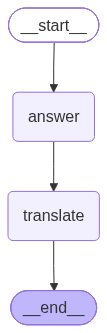

In [16]:
graph

In [19]:
graph.invoke({'question':'What is Neuroplasticity?'})

{'question': 'What is Neuroplasticity?',
 'answer_english': AIMessage(content='Neuroplasticity, often called **brain plasticity**, is the remarkable ability of the brain to **change, adapt, and reorganize itself** throughout life.\n\nIt refers to the brain\'s capacity to:\n\n1.  **Form new neural connections.**\n2.  **Strengthen or weaken existing ones.**\n3.  **Reorganize its structure and function** in response to experience, learning, environment, or injury.\n\n**In simpler terms:** Think of your brain not as a rigid, fixed structure, but more like a dynamic, ever-changing road network. New roads can be built, old roads can be expanded or closed off, and the traffic flow (neural signals) can be rerouted based on where you need to go (what you\'re learning or experiencing).\n\n**Key aspects of Neuroplasticity:**\n\n*   **Lifelong Process:** It\'s not just something that happens in childhood; the brain remains plastic throughout adulthood.\n*   **Mechanism:** It involves changes at th